In [9]:
# 🎬 Movie Recommendation System (Content-Based)

## 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set(style="whitegrid")

# Load Dataset
df = pd.read_csv("data/movies.csv")

# Keep only needed columns
df = df[['title', 'overview', 'genres', 'release_date']].dropna()

df.head()

# Parse Genres
df['genres'] = df['genres'].apply(lambda x: [g['name'] for g in ast.literal_eval(x)])
df['genres_str'] = df['genres'].apply(lambda x: " ".join(x))

# Combine Text Fields
df['combined'] = df['overview'] + " " + df['genres_str']
df['combined'].head()

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['combined'])

tfidf_matrix.shape

# Cosine Similarity Matrix
similarity_matrix = cosine_similarity(tfidf_matrix)
similarity_matrix.shape

# Recommendation Function
def recommend(title, n=5):
    if title not in df['title'].values:
        return f"Movie '{title}' not found."

    idx = df[df['title'] == title].index[0]
    scores = list(enumerate(similarity_matrix[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:n+1]

    recommendations = [df.iloc[i[0]]['title'] for i in scores]
    return recommendations

# Test the Recommender
recommend("Inception", n=5)

# Save Artifacts
import pickle

with open("tfidf.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

with open("similarity.pkl", "wb") as f:
    pickle.dump(similarity_matrix, f)

df.to_csv("processed_movies.csv", index=False)

"Artifacts saved successfully."



'Artifacts saved successfully.'

# EDA + Visualizations

C:\Users\jenas\AppData\Local\Temp\ipykernel_27148\2927913045.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


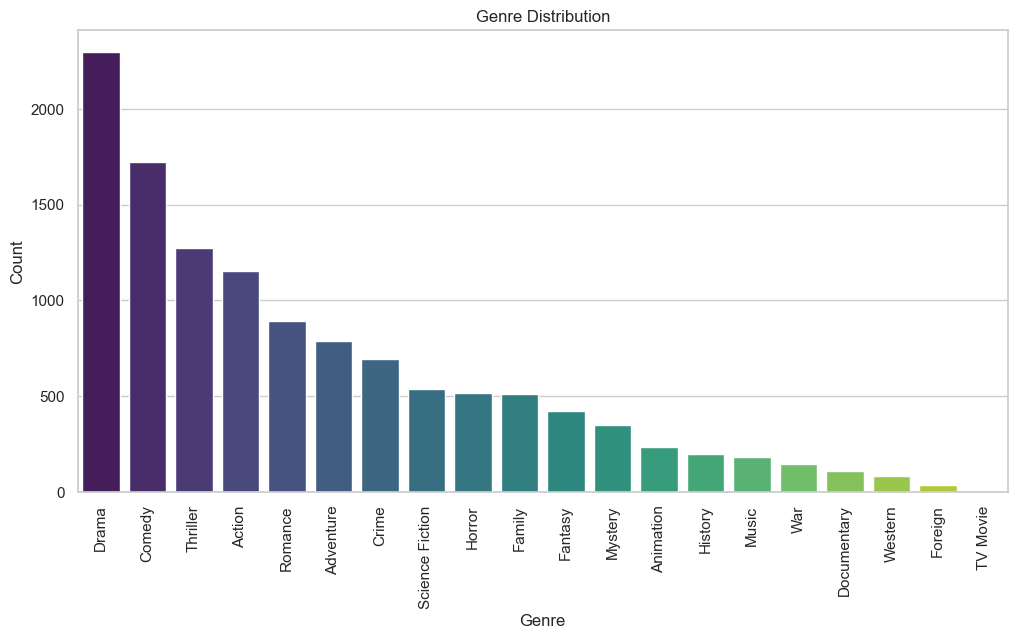

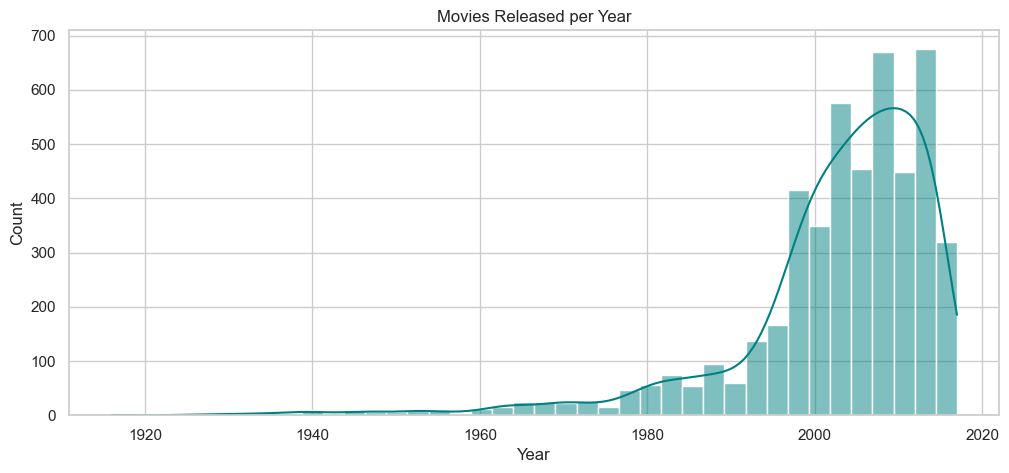

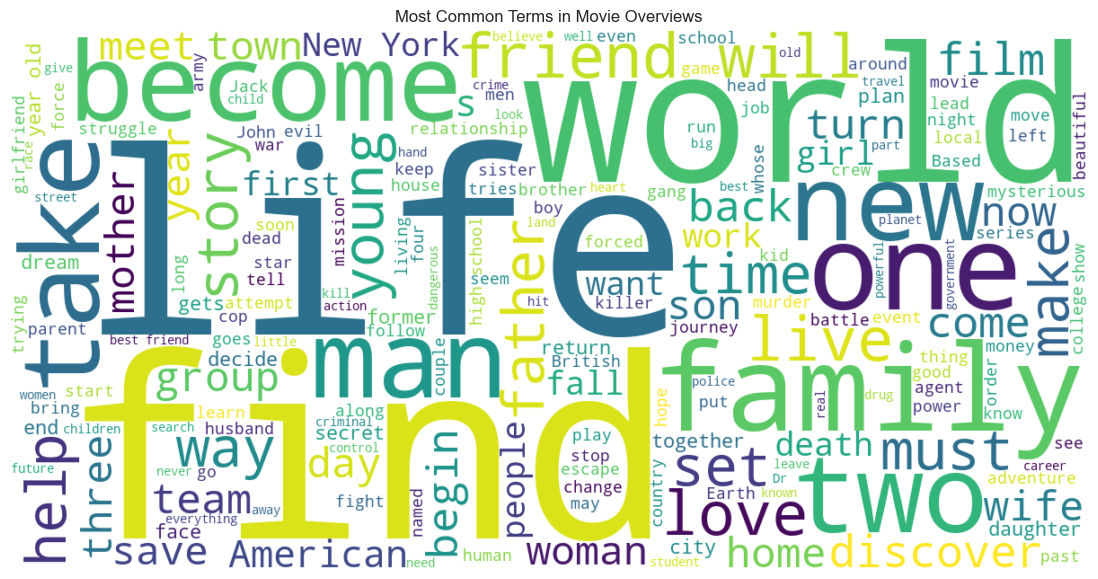

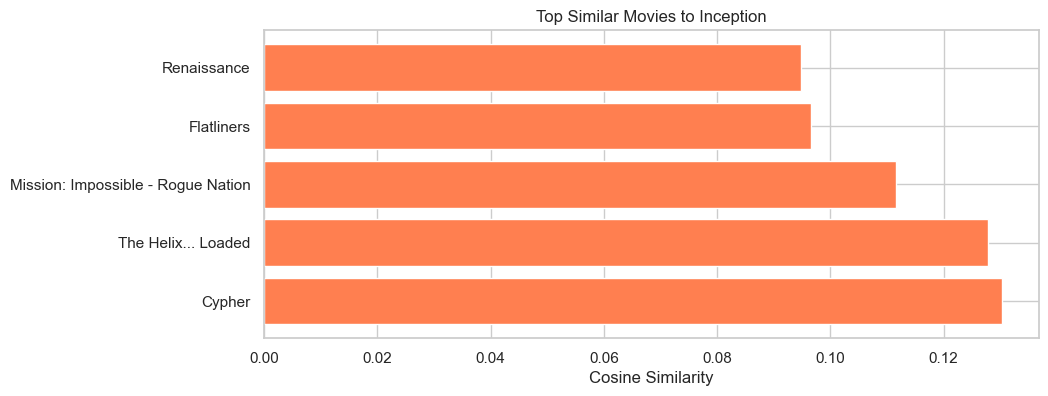

In [10]:
# Genre Distribution
genre_df = pd.DataFrame({"genre": all_genres}).reset_index(drop=True)

plt.figure(figsize=(12,6))
sns.countplot(
    data=genre_df,
    x="genre",
    order=genre_df['genre'].value_counts().index,
    palette="viridis"
)
plt.xticks(rotation=90)
plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()



#Movies Released per Year
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

plt.figure(figsize=(12,5))
sns.histplot(df['release_year'], bins=40, kde=True, color="teal")
plt.title("Movies Released per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

# Wordcloud of Movie Overviews
text = " ".join(df['overview'].astype(str).tolist())

wc = WordCloud(
    stopwords=STOPWORDS,
    background_color="white",
    width=1200,
    height=600
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Terms in Movie Overviews")
plt.show()

# Similarity Score Bar Chart
movie = "Inception"
idx = df[df['title'] == movie].index[0]

scores = similarity_matrix[idx]
top_indices = scores.argsort()[-6:-1][::-1]

plt.figure(figsize=(10,4))
plt.barh(df.iloc[top_indices]['title'], scores[top_indices], color="coral")
plt.title(f"Top Similar Movies to {movie}")
plt.xlabel("Cosine Similarity")
plt.show()
